# 04 — Diagnostic Analytics

**Project:** Explainable Scenario-Based Simulation of Aircraft Damage Consequences Among Reported Wildlife Strikes Using FAA Data

## Purpose

This notebook formally evaluates which observed characteristics are associated with **reported aircraft damage among reported wildlife strikes**. It follows the hand-off from Notebook 03 and the approved audit checklist by combining hypothesis tests, effect sizes, confidence intervals, multiplicity control, an interpretable multivariable logistic-regression baseline, and theoretically justified interaction checks.

Notebook 04 uses the canonical analytical dataset because diagnostic analysis requires access to descriptive and sensitivity variables beyond the final binary-model export. Only the explicitly listed pre-damage fields are used in the formal tests and adjusted regression. Notebook 05 will instead consume the dedicated binary-model dataset and the canonical feature lists produced by Notebook 02.

The analysis is diagnostic rather than causal. The FAA database is observational, reporting practices and field availability changed over time, and the dataset does not contain ordinary-flight exposure denominators. Therefore, results describe associations conditional on a strike being reported; they do not estimate the probability that a strike occurs and do not establish that any factor causes damage.

SHAP is not applied in this notebook because it explains the behaviour of a fitted predictive model rather than testing associations directly in the historical data. SHAP analysis will be conducted after model selection and validation.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Locate the repository root without using machine-specific paths.
ROOT = Path.cwd()

for candidate in [ROOT, *ROOT.parents]:
    if (
        (candidate / "notebooks").exists()
        and (candidate / "outputs").exists()
    ):
        ROOT = candidate
        break

DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
DOCS_DIR = ROOT / "docs"
PREP_OUTPUT_DIR = ROOT / "outputs" / "02_data_preparation"

INPUT_FILE = PROCESSED_DIR / "faa_strikes_analytical.csv"

if not INPUT_FILE.exists():
    local_candidate = Path.cwd() / "faa_strikes_analytical.csv"

    if local_candidate.exists():
        INPUT_FILE = local_candidate

FEATURE_LIST_FILE = DOCS_DIR / "feature_lists.json"
FEATURE_ELIGIBILITY_FILE = DOCS_DIR / "feature_eligibility.csv"
VALIDATION_METADATA_FILE = (
    PREP_OUTPUT_DIR
    / "validation_metadata.json"
)

OUTPUT_DIR = ROOT / "outputs" / "04_diagnostic_analysis"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [
    OUTPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    METADATA_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Canonical input:", INPUT_FILE)
print("Output folder:", OUTPUT_DIR)
print("Tables folder:", TABLE_DIR)
print("Figures folder:", FIGURE_DIR)
print("Metadata folder:", METADATA_DIR)

Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Canonical input: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
Output folder: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\04_diagnostic_analysis
Tables folder: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\04_diagnostic_analysis\tables
Figures folder: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\04_diagnostic_analysis\figures
Metadata folder: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\04_diagnostic_analysis\metadata


## 1. Load and validate the Notebook 02 hand-off

Notebook 04 consumes the same canonical analytical dataset used by the verified descriptive notebook. It does not repeat cleaning, redefine the target, or use post-event consequence fields as predictors. The primary outcome remains `INDICATED_DAMAGE`, interpreted as reported damage conditional on a reported wildlife strike.

In [2]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8", low_memory=False)

required_columns = {
    "INDEX_NR", "INDICATED_DAMAGE", "INCIDENT_YEAR", "SIZE", "NUM_STRUCK",
    "NUM_STRUCK_ORDER", "AC_CLASS", "AC_MASS_GROUP", "PHASE_OF_FLIGHT",
    "WARNED", "FAAREGION"
}
missing_required = sorted(required_columns.difference(df.columns))
if missing_required:
    raise KeyError(f"Missing required Notebook 02 fields: {missing_required}")

# Target validation
df["INDICATED_DAMAGE"] = pd.to_numeric(df["INDICATED_DAMAGE"], errors="raise").astype(int)
valid_target_values = set(df["INDICATED_DAMAGE"].dropna().unique())
if not valid_target_values.issubset({0, 1}):
    raise ValueError(f"Unexpected INDICATED_DAMAGE values: {valid_target_values}")

# Confirm the locked analytical period used upstream.
df["INCIDENT_YEAR"] = pd.to_numeric(df["INCIDENT_YEAR"], errors="coerce")

handoff_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "First year", "Last year", "Damaging records", "Damage prevalence"],
    "Value": [
        len(df), len(df.columns), int(df["INCIDENT_YEAR"].min()), int(df["INCIDENT_YEAR"].max()),
        int(df["INDICATED_DAMAGE"].sum()), float(df["INDICATED_DAMAGE"].mean())
    ]
})
display(handoff_summary)

,Metric,Value
0,Rows,319107.00000
1,Columns,150.00000
2,First year,1990.00000
3,Last year,2024.00000
4,Damaging records,20908.00000
5,Damage prevalence,0.06552


### Data hand-off decision

The diagnostic analysis uses one row per reported strike and preserves the 1990–2024 analytical period selected upstream. No cost, injury, severity, component-damage, effect, ingestion-outcome, or other post-event fields enter the tests or adjusted model. This keeps Notebook 04 aligned with the later scenario-based binary damage model and avoids target leakage.

## 2. Statistical design and interpretation rules

The notebook evaluates the following proposal-aligned questions:

1. Are larger wildlife and greater numbers struck associated with reported damage?
2. Does reported damage differ by aircraft class, aircraft mass, phase of flight, and warning status?
3. Do wildlife size and aircraft mass, or wildlife size and phase of flight, show evidence of interaction?
4. Do year and FAA region remain associated with reported damage after adjustment for the available wildlife, aircraft, and flight factors?

Because the dataset is large, p-values can become very small for differences that have little practical importance. Each result is therefore accompanied by a sample size and an effect measure. Benjamini–Hochberg false-discovery-rate adjustment is applied within related families of tests. Statistical significance is treated as supporting evidence, not as proof of importance or causation.

In [3]:
MISSING_LABELS = {
    "", "unknown", "unknown wildlife", "not reported", "unk", "zzzz",
    "nan", "none", "missing", "unavailable"
}

def known_mask(series):
    text = series.astype("string").str.strip().str.lower()
    return series.notna() & ~text.isin(MISSING_LABELS)

def save_table(table, filename):
    path = TABLE_DIR / filename
    table.to_csv(path, index=False)
    return path

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path

def bias_corrected_cramers_v(table, chi2):
    n = table.to_numpy().sum()
    r, k = table.shape
    if n <= 1 or min(r, k) <= 1:
        return np.nan
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan

def interpret_cramers_v(v):
    if pd.isna(v): return "Not estimable"
    if v < 0.05: return "Negligible"
    if v < 0.10: return "Small"
    if v < 0.20: return "Moderate"
    if v < 0.30: return "Substantial"
    return "Strong"

## 3. Categorical association tests

Pearson chi-square tests assess whether reported damage proportions differ across categories. Bias-corrected Cramér’s V summarizes association strength. The primary test uses records with known values because a large “unknown” category can measure documentation patterns as much as the factor itself. A parallel all-category result is retained as a missingness sensitivity check.

The Cramér’s V labels used below (`Negligible`, `Small`, `Moderate`, `Substantial`, and `Strong`) are project-level interpretation aids rather than universal statistical cutoffs. The numerical effect size, category rates, sample size, and substantive context remain more important than the label alone.

In [4]:
def categorical_test(data, predictor, scope="known_only"):
    work = data[[predictor, "INDICATED_DAMAGE"]].copy()
    if scope == "known_only":
        work = work.loc[known_mask(work[predictor])]
    else:
        work[predictor] = work[predictor].astype("string").fillna("Missing")
    table = pd.crosstab(work[predictor], work["INDICATED_DAMAGE"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return None
    chi2, p_value, dof, expected = stats.chi2_contingency(table)
    min_expected = float(expected.min())
    return {
        "Predictor": predictor,
        "Scope": scope,
        "N": int(table.to_numpy().sum()),
        "Categories": int(table.shape[0]),
        "Chi_square": chi2,
        "df": int(dof),
        "p_value": p_value,
        "Cramers_V": bias_corrected_cramers_v(table, chi2),
        "Minimum_expected_count": min_expected,
        "Expected_counts_below_5": int((expected < 5).sum()),
        "Chi_square_assumption_ok": bool(
            (expected.min() >= 1) and ((expected < 5).mean() <= 0.20)
        ),
    }

categorical_predictors = [
    "SIZE", "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "PHASE_OF_FLIGHT", "WARNED"
]
rows = []
for predictor in categorical_predictors:
    for scope in ["known_only", "all_categories"]:
        result = categorical_test(df, predictor, scope)
        if result:
            rows.append(result)

categorical_tests = pd.DataFrame(rows)
for scope in categorical_tests["Scope"].unique():
    idx = categorical_tests.index[categorical_tests["Scope"].eq(scope)]
    categorical_tests.loc[idx, "p_value_BH"] = multipletests(
        categorical_tests.loc[idx, "p_value"], method="fdr_bh"
    )[1]

categorical_tests["Effect_interpretation"] = categorical_tests["Cramers_V"].map(interpret_cramers_v)
categorical_tests["Reject_at_0_05_BH"] = categorical_tests["p_value_BH"] < 0.05
categorical_tests = categorical_tests.sort_values(["Scope", "Cramers_V"], ascending=[True, False])
save_table(categorical_tests, "categorical_association_tests.csv")
display(categorical_tests)

,Predictor,Scope,N,Categories,Chi_square,df,p_value,Cramers_V,Minimum_expected_count,Expected_counts_below_5,Chi_square_assumption_ok,p_value_BH,Effect_interpretation,Reject_at_0_05_BH
1,SIZE,all_categories,319107,4,33302.664349,3,0.000000e+00,0.323037,1284.264237,0,True,0.000000e+00,Strong,True
7,AC_MASS_GROUP,all_categories,319107,4,21224.305508,3,0.000000e+00,0.257881,1824.676024,0,True,0.000000e+00,Substantial,True
9,PHASE_OF_FLIGHT,all_categories,319107,12,13854.724895,11,0.000000e+00,0.208285,7.469319,0,True,0.000000e+00,Substantial,True
5,AC_CLASS,all_categories,319107,6,8958.038994,5,0.000000e+00,0.167501,0.196561,5,False,0.000000e+00,Moderate,True
11,WARNED,all_categories,319107,3,4093.990226,2,0.000000e+00,0.113240,3701.506241,0,True,0.000000e+00,Moderate,True
3,NUM_STRUCK,all_categories,319107,5,2204.708704,4,0.000000e+00,0.083045,3.734660,1,True,0.000000e+00,Small,True
0,SIZE,known_only,287615,3,32134.214490,2,0.000000e+00,0.334245,1325.520053,0,True,0.000000e+00,Strong,True
6,AC_MASS_GROUP,known_only,228162,3,9500.514732,2,0.000000e+00,0.204036,2530.750809,0,True,0.000000e+00,Substantial,True
8,PHASE_OF_FLIGHT,known_only,194586,11,4980.457714,10,0.000000e+00,0.159825,10.784496,0,True,0.000000e+00,Moderate,True
2,NUM_STRUCK,known_only,318426,4,2052.981606,3,0.000000e+00,0.080236,3.720092,1,True,0.000000e+00,Small,True


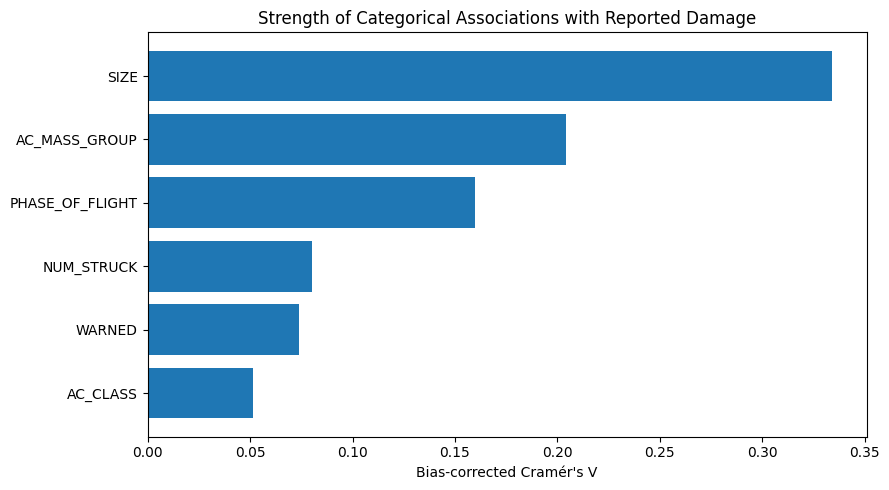

In [5]:
known_effects = categorical_tests.loc[categorical_tests["Scope"].eq("known_only")].sort_values("Cramers_V")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(known_effects["Predictor"], known_effects["Cramers_V"])
ax.set_xlabel("Bias-corrected Cramér's V")
ax.set_ylabel("")
ax.set_title("Strength of Categorical Associations with Reported Damage")
save_figure(fig, "categorical_effect_sizes.png")
plt.show()

**Assumption check**: The chi-square approximation was adequate for most primary comparisons. AC_CLASS, however, contains very sparse categories and does not satisfy the expected-count rule used here; its p-value should therefore be treated cautiously. NUM_STRUCK contains one low-expected-count cell associated with its extremely rare highest category. The effect-size and descriptive patterns remain useful, but sparse categories will require grouping or training-only rare-category handling before predictive modelling.

### How to read this section

The chi-square result answers whether category-level damage proportions differ beyond random sampling variation. Cramér’s V addresses how strongly the factor and damage status are associated. The all-category sensitivity result is not preferred for substantive interpretation when “unknown” or “not reported” is common, but a large change between scopes signals that missingness or reporting practices materially affect the apparent relationship. Statistical significance is interpreted only when the corresponding test assumptions are reasonably supported. Sparse-category results are retained as diagnostic evidence rather than treated as definitive category-level inference.

## 4. Ordered-trend tests for wildlife size and number struck

`SIZE` and `NUM_STRUCK` are not exact continuous measurements. They are ordered categories, so treating their labels as ordinary numbers or comparing raw category codes with a Mann–Whitney test would be difficult to interpret. Instead, one-predictor logistic regressions estimate the change in damage odds for a one-level increase in the documented ordering. This provides an interpretable trend estimate while acknowledging that the spacing between categories is not physically equal.

In [6]:
SIZE_ORDER = {"Small": 1, "Medium": 2, "Large": 3}
NUM_STRUCK_ORDER = {"1": 1, "2–10": 2, "11–100": 3, "More than 100": 4}

ordered_specs = {
    "Wildlife size": ("SIZE", SIZE_ORDER),
    "Number struck": ("NUM_STRUCK", NUM_STRUCK_ORDER),
}
ordered_rows = []
for label, (field, mapping) in ordered_specs.items():
    work = df[[field, "INDICATED_DAMAGE"]].copy()
    work["order"] = work[field].map(mapping)
    work = work.dropna(subset=["order", "INDICATED_DAMAGE"])
    model = smf.glm("INDICATED_DAMAGE ~ order", data=work, family=sm.families.Binomial()).fit()
    beta = model.params["order"]
    ci_low, ci_high = model.conf_int().loc["order"]
    ordered_rows.append({
        "Ordered_factor": label,
        "N": len(work),
        "Levels": len(mapping),
        "Odds_ratio_per_level": np.exp(beta),
        "CI_95_low": np.exp(ci_low),
        "CI_95_high": np.exp(ci_high),
        "p_value": model.pvalues["order"],
        "Pseudo_R2_Cox_Snell": 1 - np.exp((model.deviance - model.null_deviance) / len(work)),
    })

ordered_tests = pd.DataFrame(ordered_rows)
ordered_tests["p_value_BH"] = multipletests(ordered_tests["p_value"], method="fdr_bh")[1]
ordered_tests["Reject_at_0_05_BH"] = ordered_tests["p_value_BH"] < 0.05
save_table(ordered_tests, "ordered_trend_tests.csv")
display(ordered_tests)

,Ordered_factor,N,Levels,Odds_ratio_per_level,CI_95_low,CI_95_high,p_value,Pseudo_R2_Cox_Snell,p_value_BH,Reject_at_0_05_BH
0,Wildlife size,287615,3,4.843015,4.744762,4.943303,0.0,0.079543,0.0,True
1,Number struck,318426,4,2.044306,1.979762,2.110954,0.0,0.005133,0.0,True


In [7]:
def rate_table(data, field, order=None):
    out = (data.groupby(field, dropna=False)["INDICATED_DAMAGE"]
           .agg(Reported_Strikes="size", Damage_Records="sum", Damage_Rate="mean")
           .reset_index())
    if order is not None:
        out["_order"] = out[field].map(order)
        out = out.sort_values("_order").drop(columns="_order")
    return out

size_rates = rate_table(df.loc[df["SIZE"].isin(SIZE_ORDER)], "SIZE", SIZE_ORDER)
num_rates = rate_table(df.loc[df["NUM_STRUCK"].isin(NUM_STRUCK_ORDER)], "NUM_STRUCK", NUM_STRUCK_ORDER)
save_table(size_rates, "wildlife_size_damage_rates.csv")
save_table(num_rates, "number_struck_damage_rates.csv")
display(size_rates)
display(num_rates)

,SIZE,Reported_Strikes,Damage_Records,Damage_Rate
2,Small,196704,4011,0.020391
1,Medium,71310,8979,0.125915
0,Large,19601,6460,0.329575


,NUM_STRUCK,Reported_Strikes,Damage_Records,Damage_Rate
0,1,283177,16627,0.058716
2,2–10,33597,3810,0.113403
1,11–100,1595,325,0.203762
3,More than 100,57,20,0.350877


### Ordered-factor decision

A positive and practically noticeable odds ratio across ordered levels supports retaining wildlife size and number struck as important scenario variables. The trend model is a compact summary, not an assumption that “medium” is exactly one physical unit above “small” or that the range 11–100 has a single exact count. Later predictive preprocessing should therefore preserve these as ordered categories or compare ordered and one-hot encodings rather than inventing exact animal counts. Accordingly, the per-level odds ratios summarize the overall monotonic trend and should not be interpreted as implying that every adjacent category transition has exactly the same effect.

## 5. Multivariable logistic-regression baseline

The adjusted model estimates associations while holding the other included variables constant. It uses a focused subset of pre-damage and contextual fields selected to answer the diagnostic questions: wildlife size, number struck, aircraft class, aircraft mass group, phase of flight, warning status, FAA region, and incident year. Their eventual use as predictive inputs remains governed by the canonical Notebook 02 feature-eligibility and feature-list artifacts. Unknown/not-reported values remain explicit categories in this baseline so that the model uses the full analytical population and exposes documentation-related associations rather than hiding them through complete-case deletion.

This model is an interpretable diagnostic baseline. Notebook 05 remains responsible for split-protected preprocessing, feature selection, tuning, predictive evaluation, and final model comparison.

In [8]:
# Columns used by the adjusted logistic-regression model
model_df = df[
    [
        "INDICATED_DAMAGE",
        "INCIDENT_YEAR",
        "SIZE",
        "NUM_STRUCK",
        "AC_CLASS",
        "AC_MASS_GROUP",
        "PHASE_OF_FLIGHT",
        "WARNED",
        "FAAREGION",
    ]
].copy()

categorical_model_fields = [
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS_GROUP",
    "PHASE_OF_FLIGHT",
    "WARNED",
    "FAAREGION",
]

# Clean categorical fields.
# First use pandas string handling to replace missing values,
# then convert to ordinary Python-object strings because patsy/statsmodels
# may not support pandas' string[python] dtype.
for field in categorical_model_fields:
    model_df[field] = (
        model_df[field]
        .astype("string")
        .fillna("Missing")
        .astype("object")
    )

# Ensure numerical fields have standard numeric dtypes
model_df["INDICATED_DAMAGE"] = pd.to_numeric(
    model_df["INDICATED_DAMAGE"],
    errors="raise",
).astype(int)

model_df["INCIDENT_YEAR"] = pd.to_numeric(
    model_df["INCIDENT_YEAR"],
    errors="raise",
).astype(float)

# Center year so the model intercept refers to the median incident year
model_df["YEAR_CENTERED"] = (
    model_df["INCIDENT_YEAR"]
    - model_df["INCIDENT_YEAR"].median()
).astype(float)

# Aggregate identical predictor profiles.
# Frequency weights preserve the contribution of the original records
# while greatly reducing the number of rows fitted by the model.
group_fields = ["YEAR_CENTERED"] + categorical_model_fields

model_agg = (
    model_df
    .groupby(group_fields, dropna=False)["INDICATED_DAMAGE"]
    .agg(
        DAMAGE_COUNT="sum",
        N="size",
    )
    .reset_index()
)

# Convert again after groupby/reset_index to guarantee that patsy receives
# standard Python-object categorical columns.
for field in categorical_model_fields:
    model_agg[field] = model_agg[field].astype("object")

model_agg["YEAR_CENTERED"] = pd.to_numeric(
    model_agg["YEAR_CENTERED"],
    errors="raise",
).astype(float)

model_agg["DAMAGE_COUNT"] = pd.to_numeric(
    model_agg["DAMAGE_COUNT"],
    errors="raise",
).astype(float)

model_agg["N"] = pd.to_numeric(
    model_agg["N"],
    errors="raise",
).astype(float)

model_agg["DAMAGE_RATE"] = (
    model_agg["DAMAGE_COUNT"] / model_agg["N"]
).astype(float)

print(
    f"Individual records: {len(model_df):,}; "
    f"unique predictor profiles: {len(model_agg):,}"
)

# Optional diagnostic check
print("\nModel data types:")
print(
    model_agg[
        ["DAMAGE_RATE", "YEAR_CENTERED", "N"] + categorical_model_fields
    ].dtypes
)

# Explicit and interpretable reference categories
formula = (
    'DAMAGE_RATE ~ YEAR_CENTERED '
    '+ C(SIZE, Treatment(reference="Small")) '
    '+ C(NUM_STRUCK, Treatment(reference="1")) '
    '+ C(AC_CLASS, Treatment(reference="A")) '
    '+ C(AC_MASS_GROUP, Treatment(reference="Heavy")) '
    '+ C(PHASE_OF_FLIGHT, Treatment(reference="Approach")) '
    '+ C(WARNED, Treatment(reference="No")) '
    '+ C(FAAREGION, Treatment(reference="ASO"))'
)

adjusted_model = smf.glm(
    formula=formula,
    data=model_agg,
    family=sm.families.Binomial(),
    freq_weights=model_agg["N"],
).fit()

print(adjusted_model.summary())

Individual records: 319,107; unique predictor profiles: 49,995

Model data types:
DAMAGE_RATE        float64
YEAR_CENTERED      float64
N                  float64
SIZE                object
NUM_STRUCK          object
AC_CLASS            object
AC_MASS_GROUP       object
PHASE_OF_FLIGHT     object
WARNED              object
FAAREGION           object
dtype: object
                 Generalized Linear Model Regression Results                  
Dep. Variable:            DAMAGE_RATE   No. Observations:                49995
Model:                            GLM   Df Residuals:                   319067
Model Family:                Binomial   Df Model:                           39
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -45268.
Date:                Mon, 10 Aug 2026   Deviance:                       44536.
Time:                        10:30:53   Pearson chi2:                 7.39e+04
No

### Observed adjusted patterns
Wildlife size remained the strongest substantive association after adjustment. Relative to small wildlife, medium wildlife had approximately 5.12 times the estimated damage odds and large wildlife approximately 22.85 times the estimated odds. Greater numbers struck also showed increasing adjusted odds, while aircraft mass group and several flight phases remained associated with damage. Warning status showed a comparatively small adjusted association. Extremely rare aircraft classes produced unstable estimates and should not be interpreted individually.

In [9]:
def model_or_table(model):
    ci = model.conf_int()
    out = pd.DataFrame({
        "Term": model.params.index,
        "Coefficient": model.params.values,
        "Odds_Ratio": np.exp(np.clip(model.params.values, -700, 700)),
        "CI_95_low": np.exp(np.clip(ci[0].values, -700, 700)),
        "CI_95_high": np.exp(np.clip(ci[1].values, -700, 700)),
        "p_value": model.pvalues.values,
    })
    out = out.loc[~out["Term"].eq("Intercept")].copy()
    out["p_value_BH"] = multipletests(out["p_value"], method="fdr_bh")[1]
    out["Reject_at_0_05_BH"] = out["p_value_BH"] < 0.05
    return out

adjusted_or = model_or_table(adjusted_model)
save_table(adjusted_or, "adjusted_logistic_odds_ratios.csv")
display(adjusted_or)

model_fit = pd.DataFrame({
    "Metric": ["N", "Parameters", "AIC", "Log-likelihood", "Null deviance", "Residual deviance"],
    "Value": [model_agg["N"].sum(), adjusted_model.df_model + 1, adjusted_model.aic,
              adjusted_model.llf, adjusted_model.null_deviance, adjusted_model.deviance]
})
save_table(model_fit, "adjusted_logistic_fit_summary.csv")
display(model_fit)

,Term,Coefficient,Odds_Ratio,CI_95_low,CI_95_high,p_value,p_value_BH,Reject_at_0_05_BH
1,"C(SIZE, Treatment(reference=""Small""))[T.Large]",3.128739,2.284515e+01,2.174079e+01,2.400560e+01,0.000000e+00,0.000000e+00,True
2,"C(SIZE, Treatment(reference=""Small""))[T.Medium]",1.632763,5.117998e+00,4.905239e+00,5.339984e+00,0.000000e+00,0.000000e+00,True
3,"C(SIZE, Treatment(reference=""Small""))[T.Not re...",0.623460,1.865372e+00,1.745572e+00,1.993394e+00,1.110923e-75,4.332600e-75,True
4,"C(NUM_STRUCK, Treatment(reference=""1""))[T.11–100]",1.915255,6.788670e+00,5.887411e+00,7.827895e+00,4.615973e-153,3.600459e-152,True
5,"C(NUM_STRUCK, Treatment(reference=""1""))[T.2–10]",0.706757,2.027407e+00,1.939772e+00,2.119000e+00,9.994060e-216,9.744208e-215,True
6,"C(NUM_STRUCK, Treatment(reference=""1""))[T.More...",2.902614,1.822172e+01,9.890110e+00,3.357203e+01,1.280803e-20,3.121956e-20,True
7,"C(NUM_STRUCK, Treatment(reference=""1""))[T.Not ...",-0.844657,4.297048e-01,3.457028e-01,5.341183e-01,2.723655e-14,5.590661e-14,True
8,"C(AC_CLASS, Treatment(reference=""A""))[T.B]",-0.705580,4.938219e-01,4.430713e-01,5.503855e-01,3.026743e-37,9.080230e-37,True
9,"C(AC_CLASS, Treatment(reference=""A""))[T.C]",-0.818843,4.409414e-01,5.330900e-02,3.647214e+00,4.474894e-01,4.847802e-01,False
10,"C(AC_CLASS, Treatment(reference=""A""))[T.J]",-22.640840,1.469630e-10,9.859677e-305,1.014232e+304,9.990503e-01,9.993243e-01,False


,Metric,Value
0,N,319107.000000
1,Parameters,40.000000
2,AIC,90616.817485
3,Log-likelihood,-45268.408743
4,Null deviance,89610.638352
5,Residual deviance,44536.311022


### Adjusted-model interpretation

Odds ratios above 1 indicate higher estimated odds of reported damage relative to the stated reference category, conditional on the other model terms; odds ratios below 1 indicate lower estimated odds. They are not risk ratios and should not be translated into causal effects. Very sparse aircraft classes or phases can produce unstable estimates and wide intervals; those rows should be interpreted cautiously and later handled by defensible category grouping or rare-category preprocessing fitted on training data only.

## 6. Temporal and geographic associations after adjustment

The year coefficient tests whether a broad linear reporting-year association remains after accounting for the included factors. FAA-region coefficients compare each region with ASO while holding those factors constant. These terms may capture unmeasured fleet composition, reporting systems, operational context, wildlife ecology, airport mix, or other differences. They must not be interpreted as ordinary-flight strike risk because no flight-exposure denominator is available.

In [10]:
temporal_geographic = adjusted_or.loc[
    adjusted_or["Term"].eq("YEAR_CENTERED") |
    adjusted_or["Term"].str.contains("FAAREGION", regex=False)
].copy()
save_table(temporal_geographic, "adjusted_temporal_geographic_associations.csv")
display(temporal_geographic)

,Term,Coefficient,Odds_Ratio,CI_95_low,CI_95_high,p_value,p_value_BH,Reject_at_0_05_BH
29,"C(FAAREGION, Treatment(reference=""ASO""))[T.AAL]",0.139246,1.149407,0.963148,1.371685,1.226602e-01,1.406985e-01,False
30,"C(FAAREGION, Treatment(reference=""ASO""))[T.ACE]",0.189535,1.208687,1.104353,1.322878,3.872014e-05,6.292023e-05,True
31,"C(FAAREGION, Treatment(reference=""ASO""))[T.AEA]",0.110385,1.116708,1.054067,1.183071,1.784709e-04,2.677063e-04,True
32,"C(FAAREGION, Treatment(reference=""ASO""))[T.AGL]",0.047093,1.048219,0.986330,1.113992,1.293529e-01,1.441361e-01,False
33,"C(FAAREGION, Treatment(reference=""ASO""))[T.ANE]",-0.148282,0.862188,0.780066,0.952956,3.690259e-03,4.642584e-03,True
34,"C(FAAREGION, Treatment(reference=""ASO""))[T.ANM]",0.294759,1.342803,1.252344,1.439795,1.194615e-16,2.588333e-16,True
35,"C(FAAREGION, Treatment(reference=""ASO""))[T.ASW]",0.124418,1.132489,1.060845,1.208972,1.904194e-04,2.750503e-04,True
36,"C(FAAREGION, Treatment(reference=""ASO""))[T.AWP]",0.137696,1.147627,1.078923,1.220705,1.232449e-05,2.089805e-05,True
37,"C(FAAREGION, Treatment(reference=""ASO""))[T.FGN]",0.183490,1.201403,1.075194,1.342427,1.194163e-03,1.552412e-03,True
38,"C(FAAREGION, Treatment(reference=""ASO""))[T.Not...",1.564045,4.778109,4.093297,5.577491,2.152072e-87,9.325647e-87,True


The centered-year coefficient remained statistically detectable after adjustment, with an odds ratio of approximately 0.983 per year. This corresponds to a modest downward association in reported damage odds over the analytical period, but it must not be interpreted as a causal annual safety improvement because reporting practices, aircraft composition, wildlife identification, and other unmeasured conditions changed over time. Several FAA-region coefficients also differed from the ASO reference, although most effects were comparatively modest. The very large estimate for the `Not reported` region category is treated as documentation-related rather than geographic evidence.

## 7. Interaction assessment

Two interactions are tested because they are theoretically justified and were visible in Notebook 03:

- wildlife size × aircraft mass group;
- wildlife size × phase of flight.

Each expanded model is compared with the additive baseline using a likelihood-ratio test. Benjamini–Hochberg adjustment is applied across the interaction family. A statistically detectable interaction is considered practically useful only when it improves fit meaningfully and produces stable, interpretable category-specific estimates. Sparse combinations can create extreme coefficients and should not automatically become predictive features.

In [11]:
interaction_specs = {
    "Wildlife size × aircraft mass": (
        'C(SIZE, Treatment(reference="Small")) * '
        'C(AC_MASS_GROUP, Treatment(reference="Heavy"))'
    ),
    "Wildlife size × phase of flight": (
        'C(SIZE, Treatment(reference="Small")) * '
        'C(PHASE_OF_FLIGHT, Treatment(reference="Approach"))'
    ),
}

# Replace the relevant additive terms while preserving all other adjustment variables.
base_without_size_mass_phase = (
    'DAMAGE_RATE ~ YEAR_CENTERED '
    '+ C(NUM_STRUCK, Treatment(reference="1")) '
    '+ C(AC_CLASS, Treatment(reference="A")) '
    '+ C(WARNED, Treatment(reference="No")) '
    '+ C(FAAREGION, Treatment(reference="ASO"))'
)

interaction_rows = []
interaction_models = {}

for name, interaction_term in interaction_specs.items():

    if "aircraft mass" in name:
        interaction_fields = ["SIZE", "AC_MASS_GROUP"]
    else:
        interaction_fields = ["SIZE", "PHASE_OF_FLIGHT"]

    # Restrict only the variables involved in the interaction to known values.
    interaction_df = model_df.copy()

    mask = pd.Series(True, index=interaction_df.index)
    for field in interaction_fields:
        mask &= known_mask(interaction_df[field])

    interaction_df = interaction_df.loc[mask].copy()

    # Re-aggregate predictor profiles on the restricted population.
    interaction_agg = (
        interaction_df
        .groupby(group_fields, dropna=False)["INDICATED_DAMAGE"]
        .agg(DAMAGE_COUNT="sum", N="size")
        .reset_index()
    )

    for field in categorical_model_fields:
        interaction_agg[field] = interaction_agg[field].astype("object")

    interaction_agg["DAMAGE_RATE"] = (
        interaction_agg["DAMAGE_COUNT"] / interaction_agg["N"]
    ).astype(float)

    # Additive model fitted to the SAME records.
    additive_model = smf.glm(
        formula=formula,
        data=interaction_agg,
        family=sm.families.Binomial(),
        freq_weights=interaction_agg["N"],
    ).fit()

    if "aircraft mass" in name:
        expanded_formula = (
            base_without_size_mass_phase
            + " + "
            + interaction_term
            + ' + C(PHASE_OF_FLIGHT, Treatment(reference="Approach"))'
        )
    else:
        expanded_formula = (
            base_without_size_mass_phase
            + " + "
            + interaction_term
            + ' + C(AC_MASS_GROUP, Treatment(reference="Heavy"))'
        )

    expanded = smf.glm(
        expanded_formula,
        data=interaction_agg,
        family=sm.families.Binomial(),
        freq_weights=interaction_agg["N"],
    ).fit()

    interaction_models[name] = expanded

    lr_stat = 2 * (expanded.llf - additive_model.llf)
    df_diff = int(expanded.df_model - additive_model.df_model)
    p_value = stats.chi2.sf(lr_stat, df_diff)

    interaction_rows.append({
        "Interaction": name,
        "N": int(interaction_agg["N"].sum()),
        "Added_parameters": df_diff,
        "Likelihood_ratio_chi_square": lr_stat,
        "p_value": p_value,
        "Baseline_AIC": additive_model.aic,
        "Interaction_AIC": expanded.aic,
        "Delta_AIC": expanded.aic - additive_model.aic,
    })

interaction_tests = pd.DataFrame(interaction_rows)
interaction_tests["p_value_BH"] = multipletests(interaction_tests["p_value"], method="fdr_bh")[1]
interaction_tests["Reject_at_0_05_BH"] = interaction_tests["p_value_BH"] < 0.05
save_table(interaction_tests, "interaction_likelihood_ratio_tests.csv")
display(interaction_tests)

,Interaction,N,Added_parameters,Likelihood_ratio_chi_square,p_value,Baseline_AIC,Interaction_AIC,Delta_AIC,p_value_BH,Reject_at_0_05_BH
0,Wildlife size × aircraft mass,197437,4,73.141151,4.925482e-15,79766.903109,79701.761958,-65.141151,4.925482e-15,True
1,Wildlife size × phase of flight,168623,20,193.428264,2.234382e-30,69825.304663,69671.876399,-153.428264,4.468764e-30,True


In [12]:
interaction_term_rows = []
for name, model in interaction_models.items():
    or_table = model_or_table(model)
    terms = or_table.loc[or_table["Term"].str.contains(":", regex=False)].copy()
    terms.insert(0, "Interaction_model", name)
    interaction_term_rows.append(terms)
interaction_coefficients = pd.concat(interaction_term_rows, ignore_index=True)
save_table(interaction_coefficients, "interaction_odds_ratios.csv")
display(interaction_coefficients)

,Interaction_model,Term,Coefficient,Odds_Ratio,CI_95_low,CI_95_high,p_value,p_value_BH,Reject_at_0_05_BH
0,Wildlife size × aircraft mass,"C(SIZE, Treatment(reference=""Small""))[T.Large]...",0.491641,1.634997,1.454746,1.837581,1.592782e-16,4.081504e-16,True
1,Wildlife size × aircraft mass,"C(SIZE, Treatment(reference=""Small""))[T.Medium...",0.278111,1.320633,1.195598,1.458743,4.247675e-08,8.707734e-08,True
2,Wildlife size × aircraft mass,"C(SIZE, Treatment(reference=""Small""))[T.Large]...",0.147608,1.159058,1.020136,1.316898,2.345050e-02,2.983336e-02,True
3,Wildlife size × aircraft mass,"C(SIZE, Treatment(reference=""Small""))[T.Medium...",0.138097,1.148087,1.031962,1.277280,1.114129e-02,1.473526e-02,True
4,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Large]...",-0.458562,0.632192,0.222385,1.797187,3.896569e-01,5.417182e-01,False
5,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Medium...",-0.108717,0.896984,0.370874,2.169416,8.093476e-01,9.414860e-01,False
6,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Large]...",-0.038630,0.962106,0.837783,1.104879,5.842410e-01,7.306116e-01,False
7,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Medium...",0.009956,1.010006,0.900358,1.133008,8.651606e-01,9.483491e-01,False
8,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Large]...",-0.738201,0.477973,0.241401,0.946387,3.416907e-02,6.282699e-02,False
9,Wildlife size × phase of flight,"C(SIZE, Treatment(reference=""Small""))[T.Medium...",0.040842,1.041688,0.584903,1.855200,8.896896e-01,9.568360e-01,False


Both tested interaction specifications produced statistically detectable improvements over their corresponding additive models on the known-value analytical populations. The wildlife-size × aircraft-mass interaction produced a likelihood-ratio χ² of 73.14 with a ΔAIC of −65.14, while the wildlife-size × phase-of-flight interaction produced a likelihood-ratio χ² of 193.43 with a ΔAIC of −153.43. Both remained significant after Benjamini–Hochberg correction. These results indicate that the association between wildlife size and reported damage may vary across aircraft mass groups and phases of flight. The larger AIC improvement for the size × phase interaction suggests that it captures more additional in-sample structure than the size × mass interaction. However, these are still diagnostic, in-sample results, and some phase combinations are sparse, so neither interaction should automatically be included in Notebook 05 without validation.

### Interaction decision rule

An interaction with adjusted p < 0.05 but negligible AIC improvement, unstable intervals, or very sparse cells is retained as a diagnostic observation rather than automatically promoted to the predictive feature set. Notebook 05 should compare additive and selected interaction specifications inside the training/validation design. The final choice must be based on out-of-sample performance, calibration, stability, and scenario support—not this in-sample test alone.

## 8. Historical support for interaction cells

Interaction coefficients are especially vulnerable to sparse combinations. The following tables report record counts, damaging records, and damage rates for known wildlife-size combinations with aircraft mass and phase of flight. These counts support later warnings for rare or unsupported scenarios.

In [13]:
def interaction_support(data, fields):
    work = data[fields + ["INDICATED_DAMAGE"]].copy()
    mask = pd.Series(True, index=work.index)
    for field in fields:
        mask &= known_mask(work[field])
    work = work.loc[mask]
    out = (work.groupby(fields, dropna=False)["INDICATED_DAMAGE"]
           .agg(Reported_Strikes="size", Damage_Records="sum", Damage_Rate="mean")
           .reset_index())
    out["Sparse_under_100"] = out["Reported_Strikes"] < 100
    return out.sort_values("Reported_Strikes")

size_mass_support = interaction_support(df, ["SIZE", "AC_MASS_GROUP"])
size_phase_support = interaction_support(df, ["SIZE", "PHASE_OF_FLIGHT"])
save_table(size_mass_support, "support_size_by_aircraft_mass.csv")
save_table(size_phase_support, "support_size_by_phase.csv")
display(size_mass_support)
display(size_phase_support.head(30))

,SIZE,AC_MASS_GROUP,Reported_Strikes,Damage_Records,Damage_Rate,Sparse_under_100
2,Large,Medium,2643,1109,0.419599,False
1,Large,Light,4461,2960,0.663528,False
4,Medium,Light,6874,2366,0.344196,False
0,Large,Heavy,7226,2341,0.323969,False
5,Medium,Medium,8467,1473,0.173970,False
7,Small,Light,12595,973,0.077253,False
8,Small,Medium,20796,763,0.036690,False
3,Medium,Heavy,43122,5061,0.117365,False
6,Small,Heavy,91253,2246,0.024613,False


,SIZE,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,Damage_Rate,Sparse_under_100
8,Large,Parked,7,2,0.285714,True
1,Large,Arrival,27,8,0.296296,True
19,Medium,Parked,33,1,0.030303,True
3,Large,Departure,68,18,0.264706,True
30,Small,Parked,69,1,0.014493,True
12,Medium,Arrival,91,11,0.120879,True
7,Large,Local,105,27,0.257143,False
10,Large,Taxi,118,19,0.161017,False
21,Medium,Taxi,158,10,0.063291,False
14,Medium,Departure,180,26,0.144444,False


Wildlife-size × aircraft-mass combinations all exceeded the 100-record diagnostic support threshold. Wildlife-size × phase combinations were less uniform: several combinations, including large/parked, large/arrival, medium/parked, large/departure, small/parked, and medium/arrival, contained fewer than 100 records. These cells should not support strong individual interaction claims or unrestricted simulation scenarios without later support warnings.

## 9. Sensitivity check for recorded height, speed, and distance

Height, speed, and distance were identified descriptively as potentially informative but highly incomplete. They are not part of the primary adjusted model here because complete-case inclusion would change the analytical population substantially and could produce selection bias. A Mann–Whitney U test and rank-biserial correlation are reported as secondary diagnostics only. These tests compare distributions among records where the value was documented; they do not resolve missingness and do not justify automatic inclusion in Notebook 05.

In [14]:
def numeric_distribution_test(data, predictor):
    work = data[[predictor, "INDICATED_DAMAGE"]].copy()
    work[predictor] = pd.to_numeric(work[predictor], errors="coerce")
    work = work.dropna()
    damaged = work.loc[work["INDICATED_DAMAGE"].eq(1), predictor]
    no_damage = work.loc[work["INDICATED_DAMAGE"].eq(0), predictor]
    u_stat, p_value = stats.mannwhitneyu(damaged, no_damage, alternative="two-sided")
    # Positive value means observations in the damaging group tend to be larger.
    rank_biserial = (2 * u_stat) / (len(damaged) * len(no_damage)) - 1
    return {
        "Predictor": predictor,
        "N_documented": len(work),
        "Percent_missing": 100 * (1 - len(work) / len(data)),
        "N_damage": len(damaged),
        "N_no_damage": len(no_damage),
        "Median_damage": damaged.median(),
        "Median_no_damage": no_damage.median(),
        "Mann_Whitney_U": u_stat,
        "Rank_biserial_correlation": rank_biserial,
        "p_value": p_value,
    }

numeric_fields = [field for field in ["HEIGHT", "SPEED", "DISTANCE"] if field in df.columns]
numeric_tests = pd.DataFrame([numeric_distribution_test(df, field) for field in numeric_fields])
numeric_tests["p_value_BH"] = multipletests(numeric_tests["p_value"], method="fdr_bh")[1]
numeric_tests["Reject_at_0_05_BH"] = numeric_tests["p_value_BH"] < 0.05
save_table(numeric_tests, "numeric_distribution_sensitivity_tests.csv")
display(numeric_tests)

,Predictor,N_documented,Percent_missing,N_damage,N_no_damage,Median_damage,Median_no_damage,Mann_Whitney_U,Rank_biserial_correlation,p_value,p_value_BH,Reject_at_0_05_BH
0,HEIGHT,160917,49.572714,15806,145111,400.0,25.0,1.388060e+09,0.210363,0.000000e+00,0.000000e+00,True
1,SPEED,100786,68.416237,11728,89058,135.0,140.0,4.958638e+08,-0.050499,4.745940e-19,4.745940e-19,True
2,DISTANCE,212053,33.547995,9739,202314,0.0,0.0,1.180199e+09,0.197967,0.000000e+00,0.000000e+00,True


Documented damaging strikes tended to have higher recorded heights than non-damaging strikes, with a rank-biserial correlation of about 0.21. Recorded distance showed a similar small-to-moderate distributional separation (about 0.20), despite both groups having a median distance of zero. Speed differed statistically but showed only a very small effect (about −0.05). Because missingness is approximately 50% for height, 68% for speed, and 34% for distance, these comparisons apply only to documented subsets and do not establish that the same relationships hold among missing records.

## 10. Consolidated evidence and notebook decisions

The final evidence index combines the principal diagnostic results so that Notebook 05 and Notebook 09 can trace which associations were formally supported, how large they were, and what limitations apply.

In [15]:
evidence_rows = []
for _, row in categorical_tests.loc[categorical_tests["Scope"].eq("known_only")].iterrows():
    evidence_rows.append({
        "Question": f"Damage differs by {row['Predictor']}",
        "Method": "Pearson chi-square with BH correction",
        "N": row["N"],
        "Effect_measure": "Bias-corrected Cramer's V",
        "Effect_estimate": row["Cramers_V"],
        "Adjusted_p_value": row["p_value_BH"],
        "Practical_interpretation": row["Effect_interpretation"],
        "Decision": "Carry forward for model evaluation" if row["Cramers_V"] >= 0.05 else "Low standalone priority",
    })
for _, row in ordered_tests.iterrows():
    evidence_rows.append({
        "Question": f"Ordered trend: {row['Ordered_factor']}",
        "Method": "Univariable logistic trend with BH correction",
        "N": row["N"],
        "Effect_measure": "Odds ratio per category level",
        "Effect_estimate": row["Odds_ratio_per_level"],
        "Adjusted_p_value": row["p_value_BH"],
        "Practical_interpretation": "Increasing odds" if row["Odds_ratio_per_level"] > 1 else "Decreasing odds",
        "Decision": "Preserve ordered information; validate encoding in Notebook 05",
    })
for _, row in interaction_tests.iterrows():
    evidence_rows.append({
        "Question": row["Interaction"],
        "Method": "Likelihood-ratio test with BH correction",
        "N": row["N"],
        "Effect_measure": "Delta AIC",
        "Effect_estimate": row["Delta_AIC"],
        "Adjusted_p_value": row["p_value_BH"],
        "Practical_interpretation": "Improved in-sample fit" if row["Delta_AIC"] < -2 else "Little fit improvement",
        "Decision": "Evaluate under validation; do not force into final model",
    })

evidence_index = pd.DataFrame(evidence_rows)
save_table(evidence_index, "diagnostic_evidence_index.csv")
display(evidence_index)

,Question,Method,N,Effect_measure,Effect_estimate,Adjusted_p_value,Practical_interpretation,Decision
0,Damage differs by SIZE,Pearson chi-square with BH correction,287615,Bias-corrected Cramer's V,0.334245,0.000000e+00,Strong,Carry forward for model evaluation
1,Damage differs by AC_MASS_GROUP,Pearson chi-square with BH correction,228162,Bias-corrected Cramer's V,0.204036,0.000000e+00,Substantial,Carry forward for model evaluation
2,Damage differs by PHASE_OF_FLIGHT,Pearson chi-square with BH correction,194586,Bias-corrected Cramer's V,0.159825,0.000000e+00,Moderate,Carry forward for model evaluation
3,Damage differs by NUM_STRUCK,Pearson chi-square with BH correction,318426,Bias-corrected Cramer's V,0.080236,0.000000e+00,Small,Carry forward for model evaluation
4,Damage differs by WARNED,Pearson chi-square with BH correction,121015,Bias-corrected Cramer's V,0.074060,1.662355e-146,Small,Carry forward for model evaluation
5,Damage differs by AC_CLASS,Pearson chi-square with BH correction,228282,Bias-corrected Cramer's V,0.051352,7.850418e-130,Small,Carry forward for model evaluation
6,Ordered trend: Wildlife size,Univariable logistic trend with BH correction,287615,Odds ratio per category level,4.843015,0.000000e+00,Increasing odds,Preserve ordered information; validate encodin...
7,Ordered trend: Number struck,Univariable logistic trend with BH correction,318426,Odds ratio per category level,2.044306,0.000000e+00,Increasing odds,Preserve ordered information; validate encodin...
8,Wildlife size × aircraft mass,Likelihood-ratio test with BH correction,197437,Delta AIC,-65.141151,4.925482e-15,Improved in-sample fit,Evaluate under validation; do not force into f...
9,Wildlife size × phase of flight,Likelihood-ratio test with BH correction,168623,Delta AIC,-153.428264,4.468764e-30,Improved in-sample fit,Evaluate under validation; do not force into f...


### Final analytical decisions

1. **Wildlife size and number struck:** retain as core candidate predictors. Their order is meaningful, but their categories are ranges rather than exact physical measurements. Notebook 05 should compare suitable encodings without converting ranges to invented exact counts.
2. **Aircraft class, aircraft mass, phase of flight, and warning status:** retain for predictive evaluation when supported by the canonical eligibility table. Statistical detectability alone is insufficient; effect size, missingness, category support, and validation performance remain decisive.
3. **Year and FAA region:** preserve as contextual candidates and validation dimensions. Their adjusted associations can reflect reporting and composition changes, so they require temporal and airport-held-out checks and must not be described as causal geographic risk.
4. **Interactions:** carry forward only as candidate specifications. They must earn inclusion through out-of-sample discrimination, calibration, stability, and adequate historical support.
5. **Height, speed, and distance:** keep as extended or sensitivity features rather than mandatory core predictors because missingness is substantial and likely non-random. Missingness indicators and training-only imputation should be evaluated in Notebook 05.
6. **Leakage protection:** severity, component damage, cost, injury, fatality, operational effects, and other post-event consequence fields remain excluded from the binary predictor set.
7. **Interpretation boundary:** all findings are associations among reported strikes. They do not estimate strike occurrence, ordinary-flight risk, or causal effects.

## 11. Handoff to Notebook 05 and Notebook 09

Notebook 05 should consume the canonical feature lists and validation metadata from Notebook 02, then use these diagnostic findings to justify—not dictate—candidate predictors and interactions. It should include a majority-class baseline and logistic-regression baseline, protect chronological and final test periods, and evaluate probability quality with imbalance-aware metrics.

Notebook 09 should compare final model explanations with this diagnostic evidence. Strong disagreements may reveal nonlinear effects, interactions, category sparsity, distribution shift, or leakage and should be investigated rather than explained away.

In [16]:
run_metadata = {
    "notebook": "04_diagnostic_analytics.ipynb",
    "input_file": str(INPUT_FILE),
    "rows": int(len(df)),
    "columns": int(len(df.columns)),
    "analytical_year_start": int(df["INCIDENT_YEAR"].min()),
    "analytical_year_end": int(df["INCIDENT_YEAR"].max()),
    "target": "INDICATED_DAMAGE",
    "random_seed": RANDOM_SEED,
    "primary_categorical_tests": categorical_predictors,
    "ordered_tests": list(ordered_specs.keys()),
    "interactions_tested": list(interaction_specs.keys()),
    "adjusted_model_formula": formula,
    "interpretation": "Associations conditional on a reported wildlife strike; not causal.",
}
metadata_path = METADATA_DIR / "notebook_04_diagnostic_metadata.json"
metadata_path.write_text(json.dumps(run_metadata, indent=2), encoding="utf-8")

manifest = pd.DataFrame({
    "Artifact": sorted([p.name for p in TABLE_DIR.glob("*.csv")] +
                       [p.name for p in FIGURE_DIR.glob("*.png")] +
                       [metadata_path.name])
})
display(manifest)
print("Notebook 04 completed successfully.")

,Artifact
0,adjusted_logistic_fit_summary.csv
1,adjusted_logistic_odds_ratios.csv
2,adjusted_temporal_geographic_associations.csv
3,categorical_association_tests.csv
4,categorical_effect_sizes.png
5,diagnostic_evidence_index.csv
6,interaction_likelihood_ratio_tests.csv
7,interaction_odds_ratios.csv
8,notebook_04_diagnostic_metadata.json
9,number_struck_damage_rates.csv


Notebook 04 completed successfully.
